# Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#for data preprocessing
from sklearn.preprocessing import StandardScaler
# target is salary which is continuous
from sklearn.feature_selection import mutual_info_classif

#for linear regression model

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report


#for decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

# Read the Data

In [ ]:
# filepath to the .excel file
filepath = '/content/drive/MyDrive/Data/default of credit card clients.xls'
df_credit = pd.read_excel(filepath, header=1)
df_credit.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


EDA

In [ ]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [ ]:
df_credit.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
df_credit.shape

(30000, 25)

In [ ]:
df_credit.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

# preprocessing

In [ ]:
# Duplicate rows
df_credit.duplicated().sum()

np.int64(0)

In [ ]:
# Droping the duplicted rows
df_credit.drop_duplicates(inplace=True)

In [ ]:
#  Dropping the column Id
# df_credit.drop('ID', axis=1, inplace=True)

In [ ]:
# After the Drop
df_credit.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [ ]:
# After the Droip
df_credit.head(2)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1


In [ ]:
# check for the misiing values
df_credit.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
# Check the datatypes
df_credit.dtypes

,0
ID,int64
LIMIT_BAL,int64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64


In [ ]:
print(df_credit.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [ ]:
df_credit['default payment next month'].value_counts()

,count
default payment next month,
0,23364
1,6636


# Outlier Detection

In [ ]:
columns = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

for col in columns:
    Q1 = df_credit[col].quantile(0.25)
    Q3 = df_credit[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col}")
    print(f"Q1  : {Q1}")
    print(f"Q3  : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print("-" * 35)

LIMIT_BAL
Q1  : 50000.0
Q3  : 240000.0
IQR : 190000.0
Lower Bound : -235000.0
Upper Bound : 525000.0
-----------------------------------
AGE
Q1  : 28.0
Q3  : 41.0
IQR : 13.0
Lower Bound : 8.5
Upper Bound : 60.5
-----------------------------------
BILL_AMT1
Q1  : 3558.75
Q3  : 67091.0
IQR : 63532.25
Lower Bound : -91739.625
Upper Bound : 162389.375
-----------------------------------
BILL_AMT2
Q1  : 2984.75
Q3  : 64006.25
IQR : 61021.5
Lower Bound : -88547.5
Upper Bound : 155538.5
-----------------------------------
BILL_AMT3
Q1  : 2666.25
Q3  : 60164.75
IQR : 57498.5
Lower Bound : -83581.5
Upper Bound : 146412.5
-----------------------------------
BILL_AMT4
Q1  : 2326.75
Q3  : 54506.0
IQR : 52179.25
Lower Bound : -75942.125
Upper Bound : 132774.875
-----------------------------------
BILL_AMT5
Q1  : 1763.0
Q3  : 50190.5
IQR : 48427.5
Lower Bound : -70878.25
Upper Bound : 122831.75
-----------------------------------
BILL_AMT6
Q1  : 1256.0
Q3  : 49198.25
IQR : 47942.25
Lower Bound : -70

# Why StandardScaler for this dataset?

Your dataset contains features with very different ranges:

Feature	Approximate Range
AGE	21–79
LIMIT_BAL	10,000–1,000,000
BILL_AMT1	-165,580 to 964,511
PAY_AMT1	0–873,552

If you use MinMaxScaler, a few very large values (outliers) can compress most of the data into a narrow range between 0 and 1.

StandardScaler is generally more robust for this type of financial dataset because it centers the data around a mean of 0 with a standard deviation of 1, making optimization easier for algorithms like Logistic Regression, SVM, KNN, and ANN.

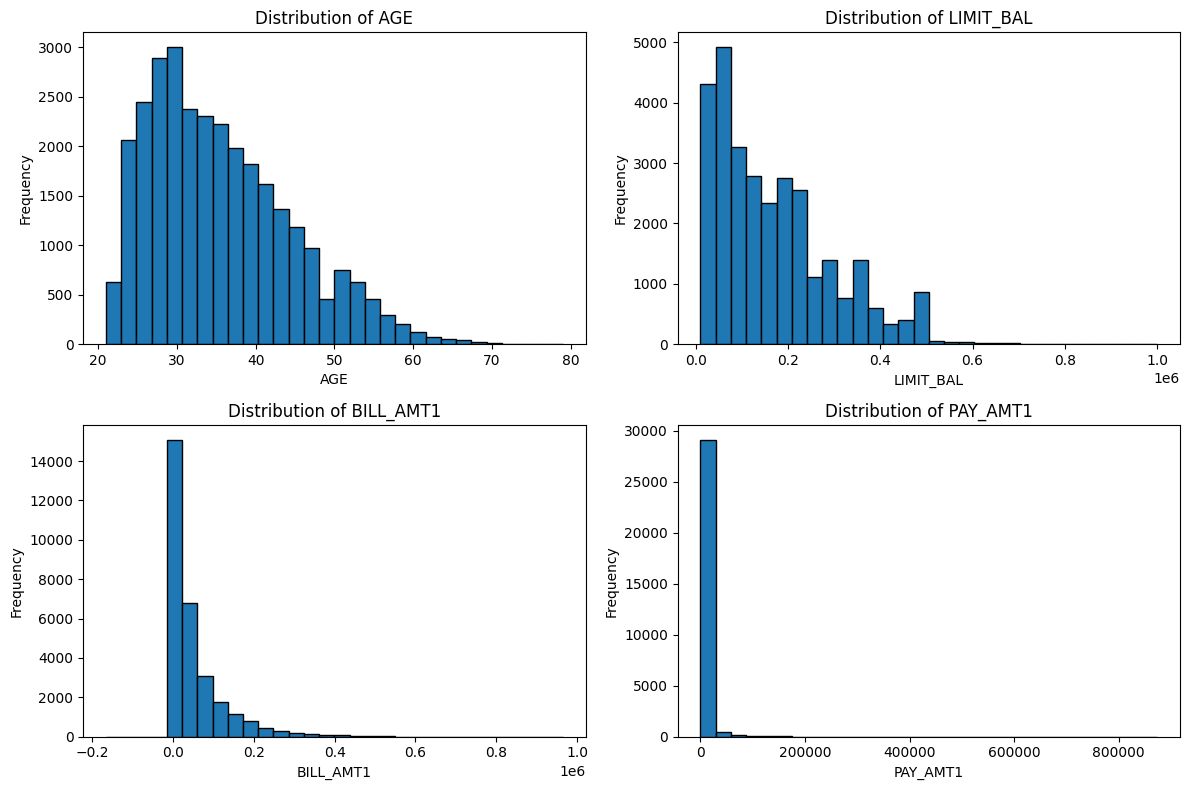

In [ ]:
# Columns to plot
columns = ['AGE', 'LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']

# Create a 2x2 grid of plots
plt.figure(figsize=(12, 8))

for i, col in enumerate(columns, 1):
    plt.subplot(2, 2, i)
    plt.hist(df_credit[col], bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

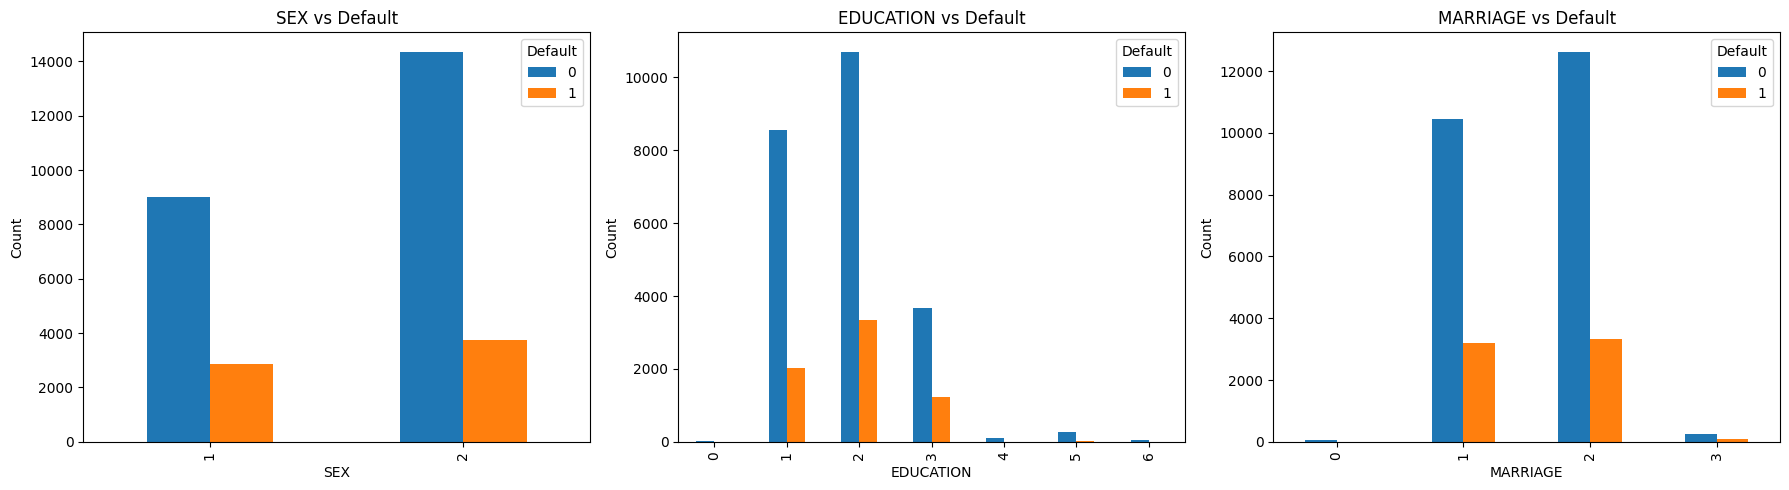

In [ ]:
# Create one figure with 3 subplots
plt.figure(figsize=(18, 5))

# SEX vs Default
plt.subplot(1, 3, 1)
pd.crosstab(df_credit['SEX'],
            df_credit['default payment next month']).plot(
    kind='bar', ax=plt.gca())
plt.title('SEX vs Default')
plt.xlabel('SEX')
plt.ylabel('Count')
plt.legend(title='Default')

# EDUCATION vs Default
plt.subplot(1, 3, 2)
pd.crosstab(df_credit['EDUCATION'],
            df_credit['default payment next month']).plot(
    kind='bar', ax=plt.gca())
plt.title('EDUCATION vs Default')
plt.xlabel('EDUCATION')
plt.ylabel('Count')
plt.legend(title='Default')

# MARRIAGE vs Default
plt.subplot(1, 3, 3)
pd.crosstab(df_credit['MARRIAGE'],
            df_credit['default payment next month']).plot(
    kind='bar', ax=plt.gca())
plt.title('MARRIAGE vs Default')
plt.xlabel('MARRIAGE')
plt.ylabel('Count')
plt.legend(title='Default')

plt.tight_layout()
plt.show()

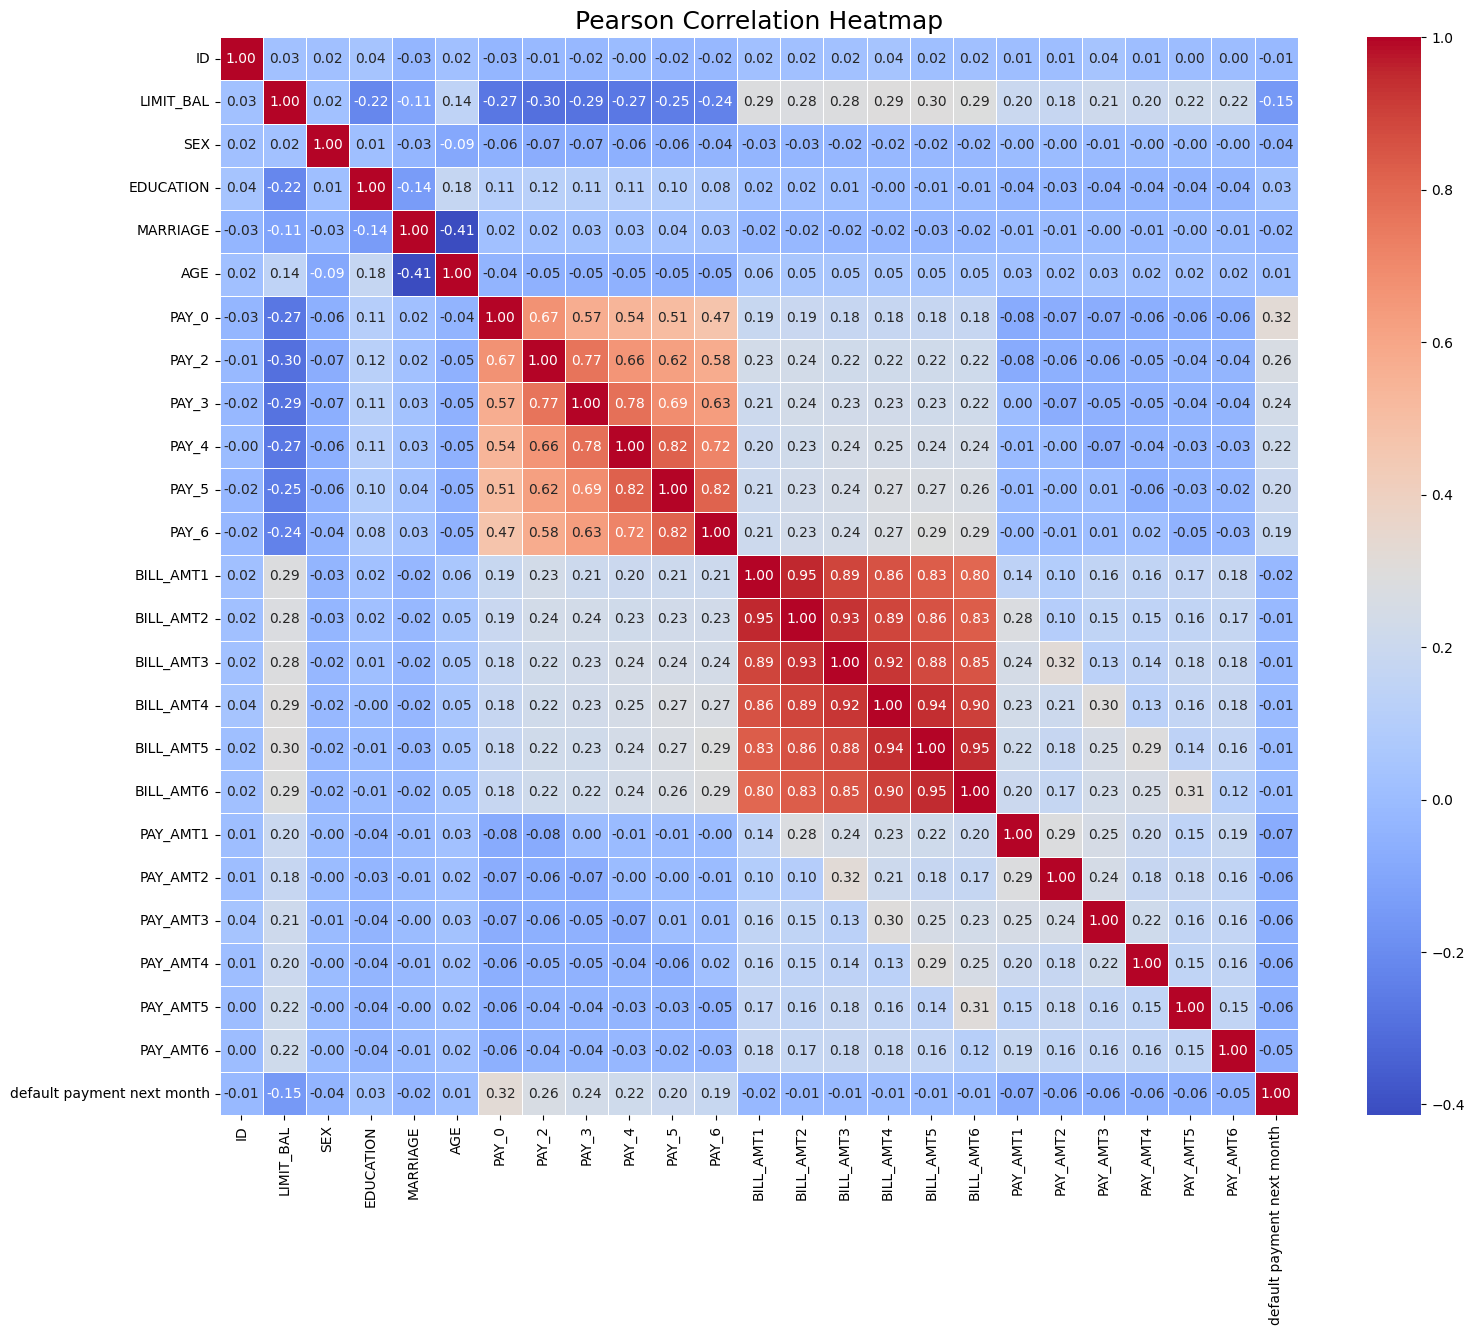

In [ ]:
# Compute Pearson correlation matrix
corr_matrix = df_credit.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt=".2f",           # Display values up to 2 decimal places
    cmap="coolwarm",     # Blue = negative, Red = positive
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Heatmap", fontsize=18)
plt.show()

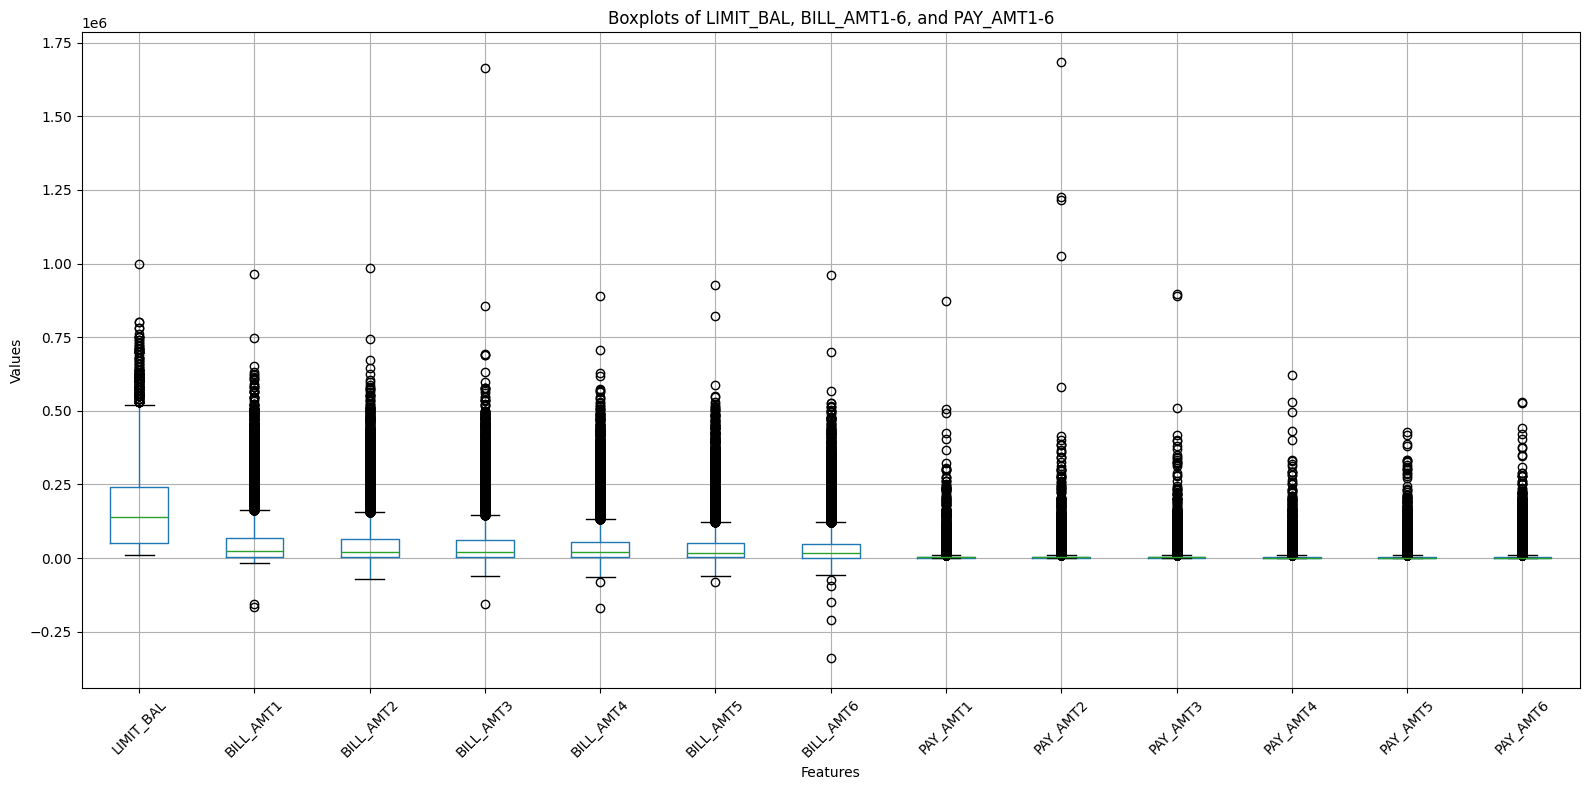

In [ ]:
# Columns for boxplots
columns = [
    'LIMIT_BAL',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

# Create one figure
plt.figure(figsize=(16, 8))

# Draw boxplots
df_credit[columns].boxplot(rot=45)

plt.title('Boxplots of LIMIT_BAL, BILL_AMT1-6, and PAY_AMT1-6')
plt.xlabel('Features')
plt.ylabel('Values')

plt.tight_layout()
plt.show()

# Scaling

In [ ]:
# Split into features and target
y=df_credit['default payment next month']                            #target
x=df_credit.drop(columns= ['default payment next month'],axis=1)

# Split into test train data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=45)

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Correlation Matrix

In [ ]:
corr = df_credit.corr()
corr

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,1.000000,0.026179,0.018497,0.039177,-0.029079,0.018678,-0.030575,-0.011215,-0.018494,-0.002735,...,0.040351,0.016705,0.016730,0.009742,0.008406,0.039151,0.007793,0.000652,0.003000,-0.013952
LIMIT_BAL,0.026179,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.018497,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,...,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,0.039177,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
MARRIAGE,-0.029079,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
AGE,0.018678,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,...,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
PAY_0,-0.030575,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,...,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794
PAY_2,-0.011215,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,...,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551
PAY_3,-0.018494,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,...,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253
PAY_4,-0.002735,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,...,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614


# Mutual Information

In [ ]:
# Calculate Mutual Information
mi = mutual_info_classif(x, y, random_state=42)

# Create a DataFrame
mi_df = pd.DataFrame({'Feature': x.columns,
    'Mutual Information': mi})

# Sort from highest to lowest
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)
mi_df

,Feature,Mutual Information
6,PAY_0,0.078646
7,PAY_2,0.049679
8,PAY_3,0.038290
9,PAY_4,0.037736
11,PAY_6,0.027586
10,PAY_5,0.025608
18,PAY_AMT1,0.023076
20,PAY_AMT3,0.019319
1,LIMIT_BAL,0.015033
19,PAY_AMT2,0.013740


In [ ]:
# Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7281666666666666
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      4734
           1       0.37      0.42      0.40      1266

    accuracy                           0.73      6000
   macro avg       0.61      0.62      0.61      6000
weighted avg       0.74      0.73      0.73      6000



In [ ]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8238333333333333
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4734
           1       0.64      0.38      0.48      1266

    accuracy                           0.82      6000
   macro avg       0.74      0.66      0.69      6000
weighted avg       0.81      0.82      0.81      6000



In [ ]:
# Adaboost
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(x_train, y_train)

y_pred_ada = ada.predict(x_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.8225
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4734
           1       0.65      0.34      0.44      1266

    accuracy                           0.82      6000
   macro avg       0.75      0.64      0.67      6000
weighted avg       0.80      0.82      0.80      6000



In [ ]:
# Gradient Boost
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.828
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      4734
           1       0.66      0.37      0.48      1266

    accuracy                           0.83      6000
   macro avg       0.76      0.66      0.69      6000
weighted avg       0.81      0.83      0.81      6000



In [ ]:
# SVM
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.825
              precision    recall  f1-score   support

           0       0.84      0.95      0.90      4734
           1       0.66      0.35      0.45      1266

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.81      0.82      0.80      6000



In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7951666666666667
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      4734
           1       0.52      0.34      0.41      1266

    accuracy                           0.80      6000
   macro avg       0.68      0.63      0.65      6000
weighted avg       0.77      0.80      0.78      6000



In [ ]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(x_train_scaled, y_train)

y_pred_nb = nb.predict(x_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7501666666666666
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      4734
           1       0.44      0.62      0.51      1266

    accuracy                           0.75      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.79      0.75      0.76      6000



In [ ]:
# Find the accuracuy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.8143333333333334


In [ ]:
# Find the precision
precision = precision_score(y_test, y_pred)
print("Precision :", precision)

Precision : 0.6704035874439462


In [ ]:
# Find the recall
recall = recall_score(y_test, y_pred)
print("Recall :", recall)

Recall : 0.23617693522906794


In [ ]:
# Find the f1_score
f1 = f1_score(y_test, y_pred)
print("F1 Score :", f1)

F1 Score : 0.3492990654205608


In [ ]:
# Find the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4587  147]
 [ 967  299]]


# Classification report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      4734
           1       0.67      0.24      0.35      1266

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.78      6000



In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8143333333333334
Precision: 0.6704035874439462
Recall   : 0.23617693522906794
F1 Score : 0.3492990654205608


In [ ]:
ann = Sequential()

# Input Layer + Hidden Layer 1
ann.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
ann.add(Dense(32, activation='relu'))

# Hidden Layer 3
ann.add(Dense(16, activation='relu'))

# Output Layer
ann.add(Dense(1, activation='sigmoid'))

NameError: name 'Sequential' is not defined

In [ ]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = ann.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred = ann.predict(X_test)

In [ ]:
# Convert Probabilities into Classes
y_pred = (y_pred > 0.5).astype(int)

In [ ]:
# Plot Training Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
# Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()